# Results
Aggregated analysis and figures for the paper.
Requires `results/fever_results.csv` and `results/hotpotqa_results.csv` (produced by notebooks 04 and 05).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

from nb_style import MODEL_LABELS, MODEL_COLORS, PROMPT_COLORS, PROMPT_COLORS_QA

RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

fever = pd.read_csv(RESULTS_DIR / "fever_results.csv")
hpqa  = pd.read_csv(RESULTS_DIR / "hotpotqa_results.csv")
print("FEVER rows:", len(fever))
print("HotpotQA rows:", len(hpqa))
fever.head()

FEVER rows: 12
HotpotQA rows: 12


,model,prompt_type,poison_rate,accuracy,macro_f1,hallucination_rate,contradiction_detection_rate
0,Qwen/Qwen3.5-2B,standard,0,0.66,0.632466,0.647059,NaN
1,Qwen/Qwen3.5-2B,standard,1,0.66,0.658730,0.411765,NaN
2,Qwen/Qwen3.5-2B,chain_of_thought,0,0.58,0.543749,0.117647,NaN
3,Qwen/Qwen3.5-2B,chain_of_thought,1,0.42,0.348914,0.235294,NaN
4,Qwen/Qwen3.5-2B,vigilant,0,0.48,0.428740,0.882353,0.0


## FEVER Results

In [2]:
PROMPT_LABELS = {
    "standard":         "Standard",
    "chain_of_thought": "CoT",
    "vigilant":         "Vigilant",
}

fever["model_label"]  = fever["model"].map(MODEL_LABELS)
fever["prompt_label"] = fever["prompt_type"].map(PROMPT_LABELS)

pivot_acc = (
    fever
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="accuracy")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_acc["delta"] = pivot_acc["r=1 (poisoned)"] - pivot_acc["r=0 (clean)"]
print("=== FEVER — Accuracy ===\n")
print(pivot_acc.round(3).to_string())

=== FEVER — Accuracy ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                  0.50            0.48  -0.02
            Standard             0.58            0.42  -0.16
            Vigilant             0.56            0.50  -0.06
Qwen3.5     CoT                  0.58            0.42  -0.16
            Standard             0.66            0.66   0.00
            Vigilant             0.48            0.48   0.00


In [3]:
pivot_f1 = (
    fever
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="macro_f1")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_f1["delta"] = pivot_f1["r=1 (poisoned)"] - pivot_f1["r=0 (clean)"]
print("=== FEVER — Macro-F1 ===\n")
print(pivot_f1.round(3).to_string())

=== FEVER — Macro-F1 ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                 0.493           0.427 -0.066
            Standard            0.517           0.386 -0.131
            Vigilant            0.521           0.447 -0.074
Qwen3.5     CoT                 0.544           0.349 -0.195
            Standard            0.632           0.659  0.026
            Vigilant            0.429           0.461  0.033


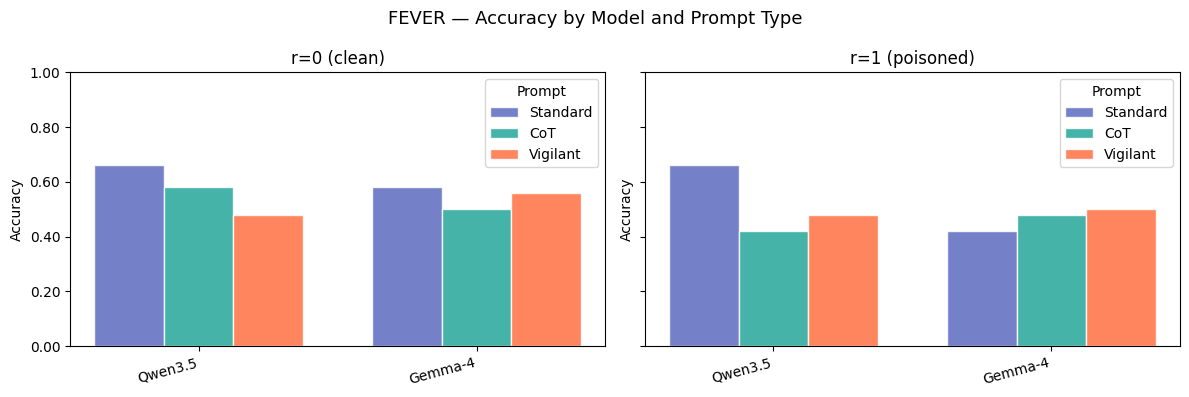

In [4]:
# Bar chart: accuracy by model, grouped by prompt, for r=0 and r=1
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
models  = list(MODEL_LABELS.values())
prompts = list(PROMPT_LABELS.values())
x = np.arange(len(models))
width = 0.25

for ax, r, title in zip(axes, [0, 1], ["r=0 (clean)", "r=1 (poisoned)"]):
    sub = fever[fever["poison_rate"] == r]
    for i, (pt_key, pt_label) in enumerate(PROMPT_LABELS.items()):
        vals = [sub[(sub["model"] == m) & (sub["prompt_type"] == pt_key)]["accuracy"].values
                for m in MODEL_LABELS]
        heights = [v[0] if len(v) else float("nan") for v in vals]
        ax.bar(x + i * width, heights, width, label=pt_label,
               color=PROMPT_COLORS[pt_key], alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.set_xticks(x + width)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(title="Prompt")
    ax.set_ylim(0, 1)

fig.suptitle("FEVER — Accuracy by Model and Prompt Type", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fever_accuracy.pdf", bbox_inches="tight")
plt.show()

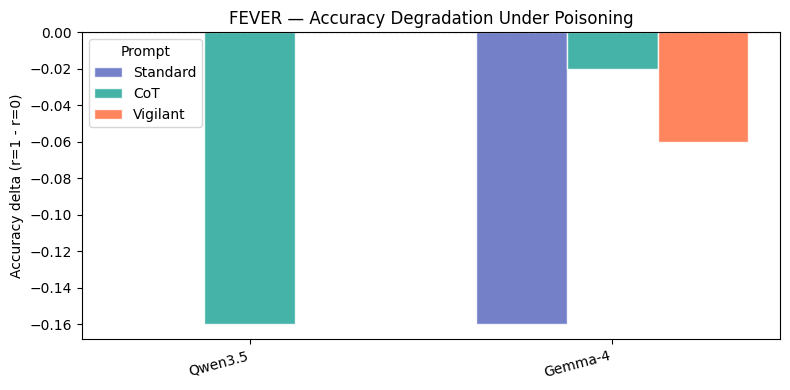

In [5]:
# Degradation: accuracy drop (r=1 - r=0) per model × prompt
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(models))
width = 0.25

for i, (pt_key, pt_label) in enumerate(PROMPT_LABELS.items()):
    deltas = []
    for m in MODEL_LABELS:
        r0 = fever[(fever["model"] == m) & (fever["prompt_type"] == pt_key)
                   & (fever["poison_rate"] == 0)]["accuracy"].values
        r1 = fever[(fever["model"] == m) & (fever["prompt_type"] == pt_key)
                   & (fever["poison_rate"] == 1)]["accuracy"].values
        deltas.append((r1[0] - r0[0]) if len(r0) and len(r1) else float("nan"))
    ax.bar(x + i * width, deltas, width, label=pt_label,
           color=PROMPT_COLORS[pt_key], alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.set_ylabel("Accuracy delta (r=1 - r=0)")
ax.set_title("FEVER — Accuracy Degradation Under Poisoning")
ax.legend(title="Prompt")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fever_degradation.pdf", bbox_inches="tight")
plt.show()

In [6]:
# Hallucination rate comparison
pivot_hal = (
    fever
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="hallucination_rate")
    .rename(columns={0: "r=0", 1: "r=1"})
)
pivot_hal["delta"] = pivot_hal["r=1"] - pivot_hal["r=0"]
print("=== FEVER — Hallucination Rate ===\n")
print(pivot_hal.round(3).to_string())

=== FEVER — Hallucination Rate ===

poison_rate                 r=0    r=1  delta
model_label prompt_label                     
Gemma-4     CoT           0.294  0.059 -0.235
            Standard      0.882  0.882  0.000
            Vigilant      0.235  0.059 -0.176
Qwen3.5     CoT           0.118  0.235  0.118
            Standard      0.647  0.412 -0.235
            Vigilant      0.882  0.765 -0.118


## HotpotQA Results

In [7]:
PROMPT_LABELS_QA = {
    "standard_qa": "Standard",
    "cot_qa":      "CoT",
    "vigilant_qa": "Vigilant",
}

hpqa["model_label"]  = hpqa["model"].map(MODEL_LABELS)
hpqa["prompt_label"] = hpqa["prompt_type"].map(PROMPT_LABELS_QA)

pivot_em = (
    hpqa
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="exact_match")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_em["delta"] = pivot_em["r=1 (poisoned)"] - pivot_em["r=0 (clean)"]
print("=== HotpotQA — Exact Match ===\n")
print(pivot_em.round(3).to_string())

pivot_tf1 = (
    hpqa
    .pivot_table(index=["model_label", "prompt_label"],
                 columns="poison_rate", values="token_f1")
    .rename(columns={0: "r=0 (clean)", 1: "r=1 (poisoned)"})
)
pivot_tf1["delta"] = pivot_tf1["r=1 (poisoned)"] - pivot_tf1["r=0 (clean)"]
print("\n=== HotpotQA — Token F1 ===\n")
print(pivot_tf1.round(3).to_string())

=== HotpotQA — Exact Match ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                  0.32            0.28  -0.04
            Standard             0.46            0.36  -0.10
            Vigilant             0.34            0.28  -0.06
Qwen3.5     CoT                  0.56            0.46  -0.10
            Standard             0.62            0.52  -0.10
            Vigilant             0.32            0.26  -0.06

=== HotpotQA — Token F1 ===

poison_rate               r=0 (clean)  r=1 (poisoned)  delta
model_label prompt_label                                    
Gemma-4     CoT                 0.463           0.409 -0.054
            Standard            0.542           0.492 -0.050
            Vigilant            0.525           0.435 -0.090
Qwen3.5     CoT                 0.690           0.592 -0.097
            Standard            0.719           0.627 -0.092
            Vigilant   

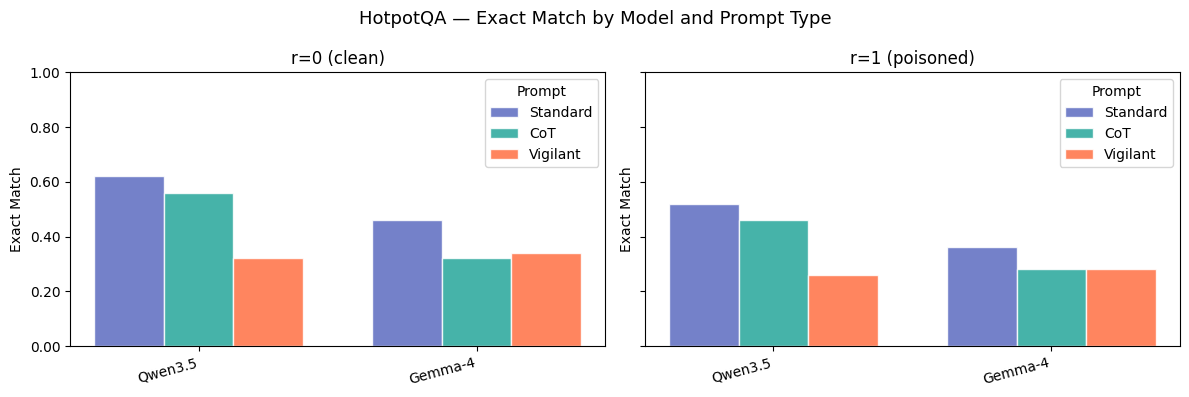

In [8]:
# HotpotQA bar charts: EM by model × prompt for r=0 and r=1
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x = np.arange(len(models))

for ax, r, title in zip(axes, [0, 1], ["r=0 (clean)", "r=1 (poisoned)"]):
    sub = hpqa[hpqa["poison_rate"] == r]
    for i, (pt_key, pt_label) in enumerate(PROMPT_LABELS_QA.items()):
        vals = [sub[(sub["model"] == m) & (sub["prompt_type"] == pt_key)]["exact_match"].values
                for m in MODEL_LABELS]
        heights = [v[0] if len(v) else float("nan") for v in vals]
        ax.bar(x + i * width, heights, width, label=pt_label,
               color=PROMPT_COLORS_QA[pt_key], alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.set_xticks(x + width)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Exact Match")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(title="Prompt")
    ax.set_ylim(0, 1)

fig.suptitle("HotpotQA — Exact Match by Model and Prompt Type", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hotpotqa_em.pdf", bbox_inches="tight")
plt.show()

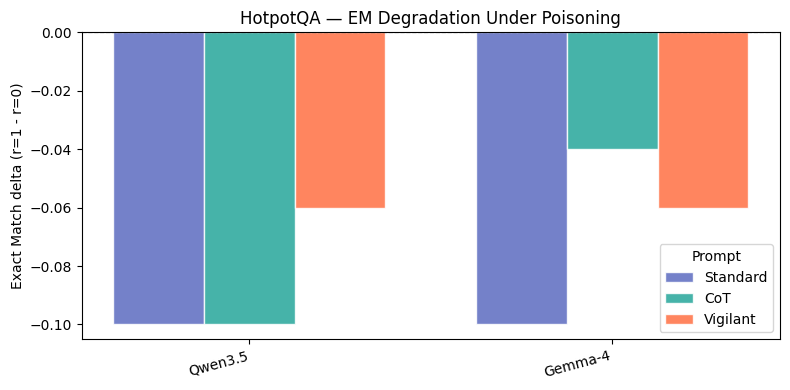

In [9]:
# HotpotQA degradation (EM drop)
fig, ax = plt.subplots(figsize=(8, 4))

for i, (pt_key, pt_label) in enumerate(PROMPT_LABELS_QA.items()):
    deltas = []
    for m in MODEL_LABELS:
        r0 = hpqa[(hpqa["model"] == m) & (hpqa["prompt_type"] == pt_key)
                  & (hpqa["poison_rate"] == 0)]["exact_match"].values
        r1 = hpqa[(hpqa["model"] == m) & (hpqa["prompt_type"] == pt_key)
                  & (hpqa["poison_rate"] == 1)]["exact_match"].values
        deltas.append((r1[0] - r0[0]) if len(r0) and len(r1) else float("nan"))
    ax.bar(x + i * width, deltas, width, label=pt_label,
           color=PROMPT_COLORS_QA[pt_key], alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.set_ylabel("Exact Match delta (r=1 - r=0)")
ax.set_title("HotpotQA — EM Degradation Under Poisoning")
ax.legend(title="Prompt")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hotpotqa_degradation.pdf", bbox_inches="tight")
plt.show()